# Quarterly Skills-Related Underemployment (SRU) by Age Group

## Dataset Description
Number and proportion of working individuals with tertiary education who are employed in **semi-skilled or low-skilled jobs**, broken down by **age group**. Quarterly data from DOSM's Labour Force Survey.

> **Why this dataset instead of Salaries by Industry?**
> The DOSM Salaries & Wages Survey (industry × sex) was hosted on `storage.googleapis.com/dosm-public-economy` — an old DOSM Google Cloud bucket that is now inaccessible from Malaysian networks. No equivalent exists on `storage.dosm.gov.my`. This SRU dataset is a direct and arguably better replacement for EduNilai, as it directly measures graduate underemployment rather than just average industry wages.

## Data Source
| Field | Detail |
|---|---|
| **Publisher** | Department of Statistics Malaysia (DOSM) |
| **Survey** | Labour Force Survey (LFS), quarterly |
| **Catalogue** | https://open.dosm.gov.my/data-catalogue/lfs_qtr_sru_age |
| **Parquet URL** | `https://storage.dosm.gov.my/labour/lfs_qtr_sru_age.parquet` |
| **CSV URL** | `https://storage.dosm.gov.my/labour/lfs_qtr_sru_age.csv` |
| **License** | CC BY 4.0 — DOSM |
| **Coverage** | 2016 Q1 – 2025 Q3 |

## Column Descriptions
| Column | Type | Description |
|---|---|---|
| `date` | date | Quarter start date (YYYY-MM-DD, DD always = 01) |
| `variable` | string | `"persons"` = count ('000); `"rate"` = proportion (%) |
| `age` | string | Age group — e.g. `15-24`, `25-34`, `35-44`, `45-54`, `55-64` |
| `sru` | float | Value — either headcount ('000) or rate (%) depending on `variable` |

> **Long format:** Filter `variable == 'rate'` for the underemployment rate (%), or `variable == 'persons'` for the headcount in thousands.

## Relevance to EduNilai
Age breakdown reveals whether **young fresh graduates (15–34)** face higher underemployment than older workers — critical for estimating the payback period of a degree. If young graduates are disproportionately underemployed in their early career years, the ROI calculation must account for a longer period of sub-optimal earnings.

In [1]:
# pip install pandas fastparquet
import pandas as pd
import matplotlib.pyplot as plt
import os

URL = 'https://storage.dosm.gov.my/labour/lfs_qtr_sru_age.parquet'
df = pd.read_parquet(URL)
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])

df

,date,variable,age,sru
0,2017-01-01,rate,overall,29.9
1,2017-04-01,rate,overall,31.8
2,2017-07-01,rate,overall,31.4
3,2017-10-01,rate,overall,32.7
4,2018-01-01,rate,overall,32.5
...,...,...,...,...
345,2024-07-01,persons,45+,245.3
346,2024-10-01,persons,45+,373.1
347,2025-01-01,persons,45+,273.6
348,2025-04-01,persons,45+,226.3


In [ ]:
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("\nDate range:", df['date'].min(), "–", df['date'].max())
print("\nUnique variable:", df['variable'].unique())
print("Unique age groups:", sorted(df['age'].unique()))

Shape: (350, 4)
Columns: ['date', 'variable', 'age', 'sru']

Date range: 2017-01-01 00:00:00 – 2025-07-01 00:00:00

Unique variable: ['rate' 'persons']
Unique age groups: ['15-24', '25-34', '35-44', '45+', 'overall']


In [5]:
# Split long format into rate and persons
df_rate    = df[df['variable'] == 'rate'].copy()
df_persons = df[df['variable'] == 'persons'].copy()

print("Latest quarter — SRU rate by age group:")
latest = df_rate[df_rate['date'] == df_rate['date'].max()]
print(latest[['age', 'sru']].sort_values('age').to_string(index=False))

Latest quarter — SRU rate by age group:
    age  sru
  15-24 74.3
  25-34 41.0
  35-44 24.9
    45+ 22.1
overall 35.5


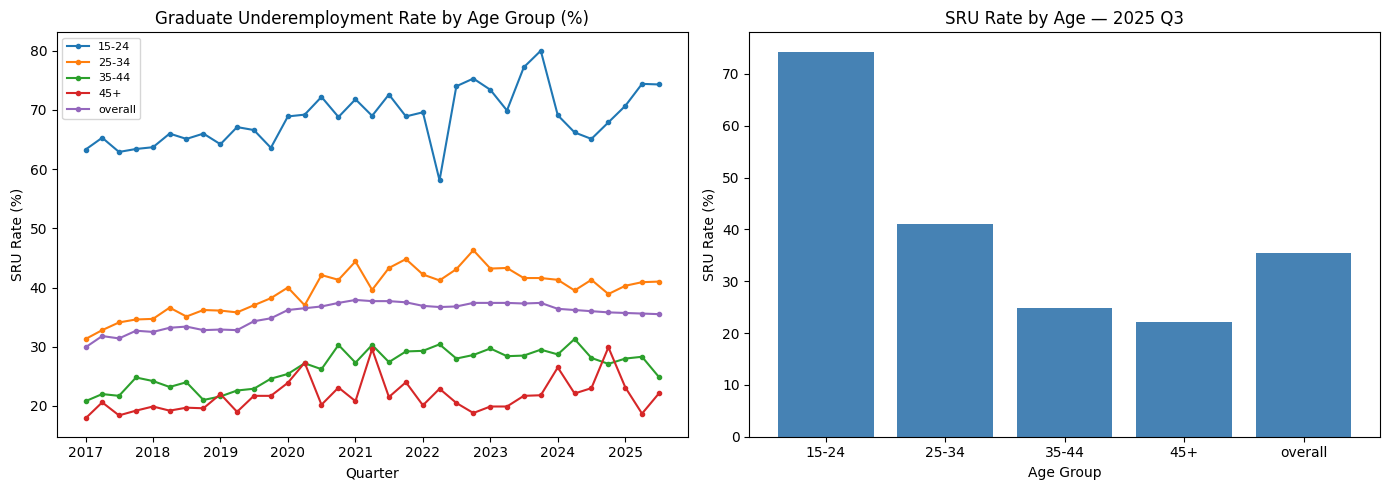

In [6]:
# Plot: SRU rate by age group over time
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for age, grp in df_rate.groupby('age'):
    axes[0].plot(grp['date'], grp['sru'], label=age, marker='o', markersize=3)
axes[0].set_title('Graduate Underemployment Rate by Age Group (%)')
axes[0].set_ylabel('SRU Rate (%)')
axes[0].set_xlabel('Quarter')
axes[0].legend(fontsize=8)

# Latest quarter bar chart
latest_sorted = latest.sort_values('age')
axes[1].bar(latest_sorted['age'], latest_sorted['sru'], color='steelblue')
axes[1].set_title(f"SRU Rate by Age — {latest['date'].max().strftime('%Y Q') + str((latest['date'].max().month-1)//3+1)}")
axes[1].set_ylabel('SRU Rate (%)')
axes[1].set_xlabel('Age Group')

plt.tight_layout()
plt.show()

In [4]:
# convert long to wide format for easier analysis
df_wide = df.pivot(index=['date', 'age'], columns='variable', values='sru').reset_index()
df_wide

variable,date,age,persons,rate
0,2017-01-01,15-24,280.8,63.3
1,2017-01-01,25-34,569.0,31.3
2,2017-01-01,35-44,209.3,20.8
3,2017-01-01,45+,123.8,17.9
4,2017-01-01,overall,1182.9,29.9
...,...,...,...,...
170,2025-07-01,15-24,466.5,74.3
171,2025-07-01,25-34,786.8,41.0
172,2025-07-01,35-44,447.8,24.9
173,2025-07-01,45+,260.4,22.1


In [7]:
# rename columns for clarity
df_wide = df_wide.rename(columns={'rate': 'sru_rate', 'persons': 'sru_persons'})
df_wide.columns

Index(['date', 'age', 'sru_persons', 'sru_rate'], dtype='object', name='variable')

In [8]:
os.makedirs('../data/salary', exist_ok=True)
df_wide.to_csv('../data/salary/graduate_underemployment_age.csv', index=False, encoding='utf-8')
print("Saved -> ../data/salary/graduate_underemployment_age.csv")
print(f"Rows: {len(df_wide)}")

Saved -> ../data/salary/graduate_underemployment_age.csv
Rows: 175
